In [243]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [244]:
FileType= input("Enter file type: ").capitalize().strip()

class Filereader:
    def __init__(self):
        self.path =  input("Enter file path: ").strip().strip('"')
        self.sheet = input("Enter sheet name: ")
        self.col = input("Enter columns : ")
        self.row = input("Enter rows name: ")

class CsvReader(Filereader):
    def read(self):
        return pd.read_csv(self.path, usecols=self.col.split(',') if self.col else None ,
                           nrows=int(self.row) if self.row else None)
class XlsReader(Filereader):
    def read(self):
        return pd.read_excel(self.path, sheet_name=self.sheet or 0,
                             usecols=self.col or None,
                             nrows=int(self.row) if self.row else None)

data = None

if FileType in ['Excel', 'Xlsx', 'Xls']:
    try:
        data = XlsReader()
        data = data.read()
    except FileNotFoundError as e:
        print(e)
    except ValueError as e:
        print("Wrong sheet, columns, or rows:", e)

elif FileType == 'Csv':
    try:
        data = CsvReader()
        data = data.read()
    except FileNotFoundError as e:
        print(e)
    except ValueError as e:
        print("Wrong columns or rows:", e)

else:
    print("Unknown file type")

data



1-Import the dataset using Pandas and inspect the dataset structure and metadata.
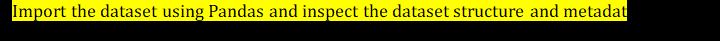
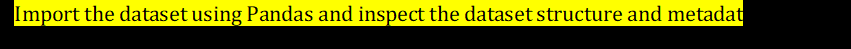

In [245]:
data


,Order ID,Year,Month,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Client Segment,Country,...,Product Category,Sub-Category,Product Name,Sales Price,Quantity,Discount,Total Sales Amount,Purchasing Price,Total Purchasing Amounts,Net Profit
0,CA-2016-152156,2020.0,Nov,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,...,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2.0,0.0,523.9200,157.17600,314.35200,209.56800
1,CA-2016-152156,2020.0,Nov,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,...,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3.0,0.0,2195.8200,402.56700,1207.70100,988.11900
2,CA-2016-138688,2020.0,Jun,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,...,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2.0,0.0,29.2400,8.77200,17.54400,11.69600
3,US-2015-108966,2020.0,Oct,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,...,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5.0,0.0,4787.8875,478.78875,2393.94375,2393.94375
4,US-2015-108966,2020.0,Oct,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,...,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2.0,0.0,35.7888,11.18400,22.36800,13.42080
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1006,Train,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1007,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1008,CA-2015-108665,2015.0,Jul,2015-07-06,2015-07-10,Standard Class,KM-16225,Kalyca Meade,Corporate,United States,...,Technology,Phones,OtterBox Commuter Series Case - Samsung Galaxy S4,124.9500,5.0,0.0,624.7500,87.46500,437.32500,187.42500
1009,CA-2015-108665,2015.0,Jul,2015-07-06,2015-07-10,Standard Class,KM-16225,Kalyca Meade,Corporate,United States,...,Technology,Phones,OtterBox Commuter Series Case - Samsung Galaxy S4,124.9500,5.0,0.0,624.7500,87.46500,437.32500,187.42500


In [246]:
data.columns

Index(['Order ID', 'Year', 'Month', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Client Segment', 'Country', 'State',
       'Postal Code', 'Region', 'Product ID', 'Product Category',
       'Sub-Category', 'Product Name', 'Sales Price', 'Quantity', 'Discount',
       'Total Sales Amount', 'Purchasing Price', 'Total Purchasing Amounts',
       'Net Profit'],
      dtype='str')

In [247]:
data.dtypes

Order ID                               str
Year                               float64
Month                                  str
Order Date                  datetime64[us]
Ship Date                   datetime64[us]
Ship Mode                              str
Customer ID                            str
Customer Name                          str
Client Segment                         str
Country                                str
State                                  str
Postal Code                        float64
Region                                 str
Product ID                             str
Product Category                       str
Sub-Category                           str
Product Name                           str
Sales Price                        float64
Quantity                           float64
Discount                           float64
Total Sales Amount                 float64
Purchasing Price                   float64
Total Purchasing Amounts           float64
Net Profit 

In [248]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1011 entries, 0 to 1010
Data columns (total 24 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Order ID                  1010 non-null   str           
 1   Year                      1009 non-null   float64       
 2   Month                     1009 non-null   str           
 3   Order Date                1009 non-null   datetime64[us]
 4   Ship Date                 1009 non-null   datetime64[us]
 5   Ship Mode                 1009 non-null   str           
 6   Customer ID               1009 non-null   str           
 7   Customer Name             1009 non-null   str           
 8   Client Segment            1009 non-null   str           
 9   Country                   1009 non-null   str           
 10  State                     1009 non-null   str           
 11  Postal Code               1009 non-null   float64       
 12  Region                    1009 

In [249]:
data.describe()

,Year,Order Date,Ship Date,Postal Code,Sales Price,Quantity,Discount,Total Sales Amount,Purchasing Price,Total Purchasing Amounts,Net Profit
count,1009.000000,1009,1009,1009.000000,1009.000000,1009.000000,1009.0,1009.000000,1009.000000,1009.000000,1009.000000
mean,2015.783944,2016-04-04 04:12:36.392467,2016-04-08 04:26:52.685827,53725.070367,240.679846,3.821606,0.0,1133.573232,144.770227,732.773092,400.800140
min,2014.000000,2014-01-04 00:00:00,2014-01-08 00:00:00,1841.000000,1.080000,1.000000,0.0,1.680000,0.648000,0.924000,0.520000
25%,2015.000000,2015-04-26 00:00:00,2015-05-02 00:00:00,19143.000000,18.504000,2.000000,0.0,45.240000,11.116000,29.600000,13.284000
50%,2016.000000,2016-05-30 00:00:00,2016-06-04 00:00:00,52601.000000,55.980000,3.000000,0.0,164.332800,33.288000,113.568000,53.913600
75%,2017.000000,2017-04-07 00:00:00,2017-04-11 00:00:00,85254.000000,210.980000,5.000000,0.0,733.530000,123.232200,487.368750,229.920000
max,2020.000000,2017-12-30 00:00:00,2018-01-05 00:00:00,98661.000000,8159.952000,14.000000,0.0,65279.616000,5303.968800,42431.750400,22847.865600
std,1.288264,NaN,NaN,31712.033257,596.912003,2.289965,0.0,3709.116919,360.460616,2301.177270,1471.255045


In [250]:
data.describe(include= 'str')

,Order ID,Month,Ship Mode,Customer ID,Customer Name,Client Segment,Country,State,Region,Product ID,Product Category,Sub-Category,Product Name
count,1010,1009,1009,1009,1009,1009,1009,1009,1009,1009,1009,1009,1009
unique,490,12,4,366,366,3,1,40,4,765,3,17,764
top,CA-2017-117457,Dec,Standard Class,TB-21520,Tracy Blumstein,Consumer,United States,California,East,TEC-AC-10003832,Office Supplies,Binders,Easy-staple paper
freq,9,153,588,12,12,556,1009,187,314,5,609,146,4


In [251]:
data.isna().sum().sum() / data.size * 100

np.float64(0.19370260468183317)

In [252]:
data.isna().sum()

Order ID                    1
Year                        2
Month                       2
Order Date                  2
Ship Date                   2
Ship Mode                   2
Customer ID                 2
Customer Name               2
Client Segment              2
Country                     2
State                       2
Postal Code                 2
Region                      2
Product ID                  2
Product Category            2
Sub-Category                2
Product Name                2
Sales Price                 2
Quantity                    2
Discount                    2
Total Sales Amount          2
Purchasing Price            2
Total Purchasing Amounts    2
Net Profit                  2
dtype: int64

In [253]:
data[data.isna().any(axis=1)]

,Order ID,Year,Month,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Client Segment,Country,...,Product Category,Sub-Category,Product Name,Sales Price,Quantity,Discount,Total Sales Amount,Purchasing Price,Total Purchasing Amounts,Net Profit
1006,Train,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1007,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [254]:
data[data.duplicated()]

,Order ID,Year,Month,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Client Segment,Country,...,Product Category,Sub-Category,Product Name,Sales Price,Quantity,Discount,Total Sales Amount,Purchasing Price,Total Purchasing Amounts,Net Profit
1009,CA-2015-108665,2015.0,Jul,2015-07-06,2015-07-10,Standard Class,KM-16225,Kalyca Meade,Corporate,United States,...,Technology,Phones,OtterBox Commuter Series Case - Samsung Galaxy S4,124.95,5.0,0.0,624.75,87.465,437.325,187.425


2-Perform advanced data cleaning including handling missing values, outliers, inconsistent formats, and duplicate records.

In [255]:
class ChekingID:
    def check_product_id(self, data):
        ok = data['Product ID'].str.match(r'^[A-Z]{3}-[A-Z]{2}-\d{8}$', na=False)
        bad = data[~ok]

        if bad.empty:
            print('Product IDs look fine')
        else:
            print(f'ALERT: {len(bad)} row(s) have a bad Product ID')
        return bad

    def check_order_id(self, data):
        ok = data['Order ID'].str.match(r'^[A-Z]{2}-\d{4}-\d+$', na=False)
        bad = data[~ok]

        if bad.empty:
            print('Order IDs look fine')
        else:
            print(f'ALERT: {len(bad)} row(s) have a bad Order ID')
        return bad


process =ChekingID()



process.check_order_id(data)

process.check_product_id(data)





ALERT: 3 row(s) have a bad Order ID
ALERT: 2 row(s) have a bad Product ID


,Order ID,Year,Month,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Client Segment,Country,...,Product Category,Sub-Category,Product Name,Sales Price,Quantity,Discount,Total Sales Amount,Purchasing Price,Total Purchasing Amounts,Net Profit
1006,Train,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1007,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [256]:
class Processing:

    def Duplicates(self, data):
        if data.duplicated().sum() > 0:
            data.drop_duplicates(keep='last', inplace=True)
            data.reset_index(drop=True ,inplace=True)
        else:
            print('No exact duplicates')

        mask = data.duplicated(subset=['Order ID', 'Product ID'], keep=False)
        if not mask.any():
            print('No partial duplicate')
        return data[mask]

    def HandlingNan(self,data):
        pct = (data.isna().sum().sum() / data.size) *100
        if pct ==0 :
            print('No nulls')
        elif pct <=5 :
            min_non_null = int(data.shape[1] // 1.5)
            data.dropna(thresh  = min_non_null,inplace=True)
            data.reset_index(drop=True ,inplace=True)
            for x in data.columns:
                if data[x].isna().any():
                    if pd.api.types.is_numeric_dtype(data[x]):
                        data[x] = data[x].fillna(data[x].median())
                    elif  pd.api.types.is_datetime64_dtype(data[x]):
                        data[x] = data[x].ffill()
                    else:
                        data[x] = data[x].fillna(data[x].mode()[0])
        else:
            print('Nulls are >5% check business rule')
        return data


class Outliers:
    def bounds(self,data,col):
        if not pd.api.types.is_numeric_dtype(data[col]) or col in ['Postal Code', 'Year']:
            raise ValueError('not numeric column')
        q1 ,q3 = data[col].quantile(0.25) ,data[col].quantile(0.75)
        IQR = q3 - q1
        return q1 - 1.5 * IQR, q3 + 1.5 * IQR
    def detect(self, data, col):
        lower, upper = self.bounds(data, col)
        return data[(data[col] > upper) | (data[col] < lower)]

    def clip(self,data,col):
        lower , upper = self.bounds(data,col)
        new =data.copy()
        new[col]= data[col].clip(lower,upper)
        return new
    def trim(self,data,col):
        lower , upper = self.bounds(data,col)

        inside= data[col].between(lower,upper)
        return data[inside].copy()
    def winsorize(self,data,col,p=0.05):
        new = data.copy()
        new[col] = data[col].clip(data[col].quantile(p), data[col].quantile(1 - p))
        return new




process = Processing()

process.Duplicates(data)

process.HandlingNan(data)

s =Outliers()

s.winsorize(data,'Total Sales Amount')
s.clip(data,'Total Sales Amount')
s.winsorize(data,'Total Sales Amount')
s.trim(data,'Total Sales Amount')


,Order ID,Year,Month,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Client Segment,Country,...,Product Category,Sub-Category,Product Name,Sales Price,Quantity,Discount,Total Sales Amount,Purchasing Price,Total Purchasing Amounts,Net Profit
0,CA-2016-152156,2020.0,Nov,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,...,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.960,2.0,0.0,523.9200,157.176,314.352,209.5680
2,CA-2016-138688,2020.0,Jun,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,...,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.620,2.0,0.0,29.2400,8.772,17.544,11.6960
4,US-2015-108966,2020.0,Oct,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,...,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.368,2.0,0.0,35.7888,11.184,22.368,13.4208
5,CA-2014-115812,2020.0,Jun,2014-06-09,2014-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,...,Furniture,Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.860,7.0,0.0,342.0200,31.759,222.313,119.7070
6,CA-2014-115812,2020.0,Jun,2014-06-09,2014-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,...,Office Supplies,Art,Newell 322,7.280,4.0,0.0,29.1200,4.368,17.472,11.6480
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1002,US-2015-126214,2015.0,Dec,2015-12-21,2015-12-24,Second Class,JS-15880,John Stevenson,Consumer,United States,...,Technology,Accessories,Enermax Acrylux Wireless Keyboard,99.600,1.0,0.0,99.6000,49.800,49.800,49.8000
1003,CA-2015-133025,2015.0,Sep,2015-09-17,2015-09-19,Second Class,MO-17800,Meg O'Connel,Home Office,United States,...,Office Supplies,Paper,Xerox 216,32.400,5.0,0.0,162.0000,21.060,105.300,56.7000
1004,CA-2015-108665,2015.0,Jul,2015-07-06,2015-07-10,Standard Class,KM-16225,Kalyca Meade,Corporate,United States,...,Furniture,Furnishings,G.E. Halogen Desk Lamp Bulbs,13.960,2.0,0.0,27.9200,8.376,16.752,11.1680
1005,CA-2015-108665,2015.0,Jul,2015-07-06,2015-07-10,Standard Class,KM-16225,Kalyca Meade,Corporate,United States,...,Furniture,Furnishings,"Howard Miller 11-1/2"" Diameter Ridgewood Wall ...",155.820,3.0,0.0,467.4600,109.074,327.222,140.2380


In [259]:
def Featuring(data):
    data['Shipping Days'] = (data['Ship Date'] - data['Order Date']).dt.days
    data['Profit Margin'] = data['Net Profit'] / data['Total Sales Amount']
    data['Sales Performance Category'] = pd.qcut(
            data['Total Sales Amount'],
            q=3,
            labels=['Low', 'Medium', 'High']
        )


Featuring(data)

Univariate


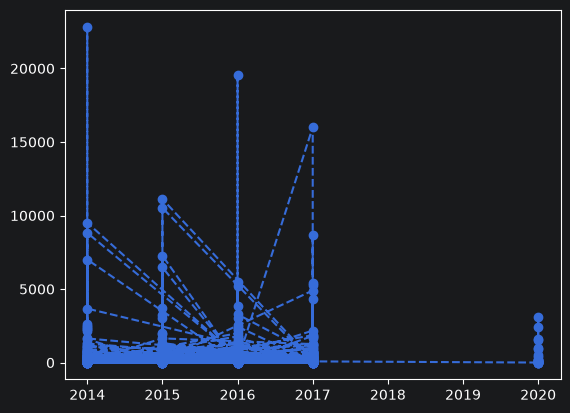

In [261]:
plt.plot(data['Year'],data['Net Profit'],linestyle='--',marker='o')

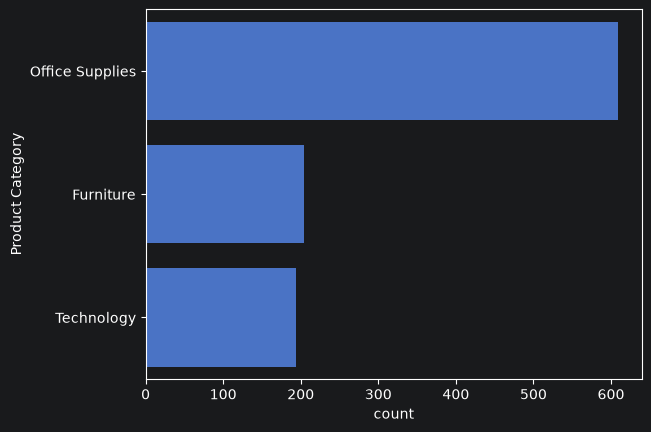

In [262]:
sns.countplot(
    data=data,
    y='Product Category',
    order=data['Product Category'].value_counts().index
)
plt.show()

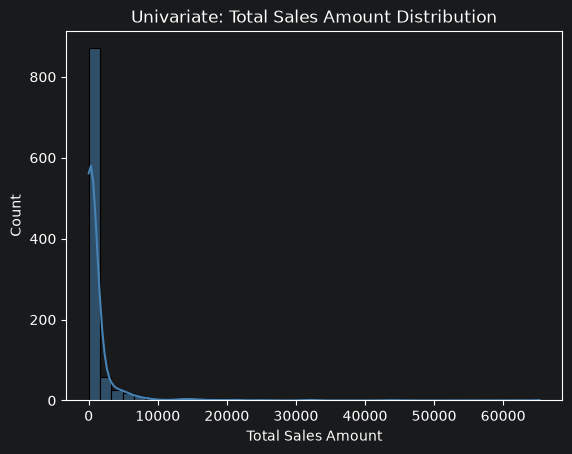

In [263]:
sns.histplot(data['Total Sales Amount'], kde=True, bins=40, color='steelblue')
plt.title('Univariate: Total Sales Amount Distribution')
plt.show()

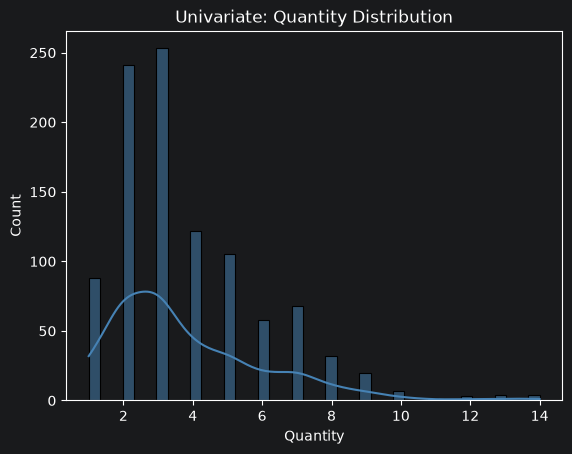

In [264]:
sns.histplot(data['Quantity'], kde=True, bins=40, color='steelblue')
plt.title('Univariate: Quantity Distribution')
plt.show()

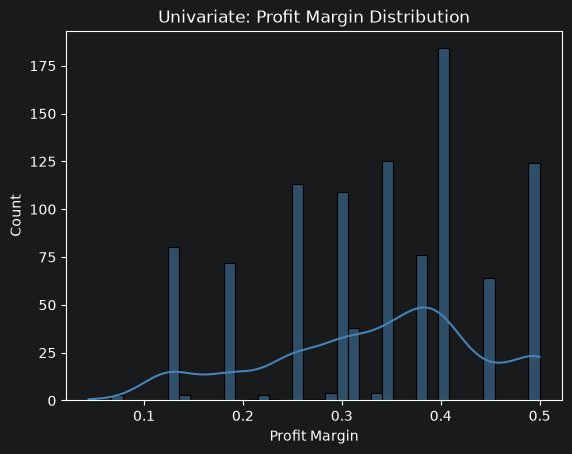

In [265]:
sns.histplot(data['Profit Margin'], kde=True, bins=40, color='steelblue')
plt.title('Univariate: Profit Margin Distribution')
plt.show()

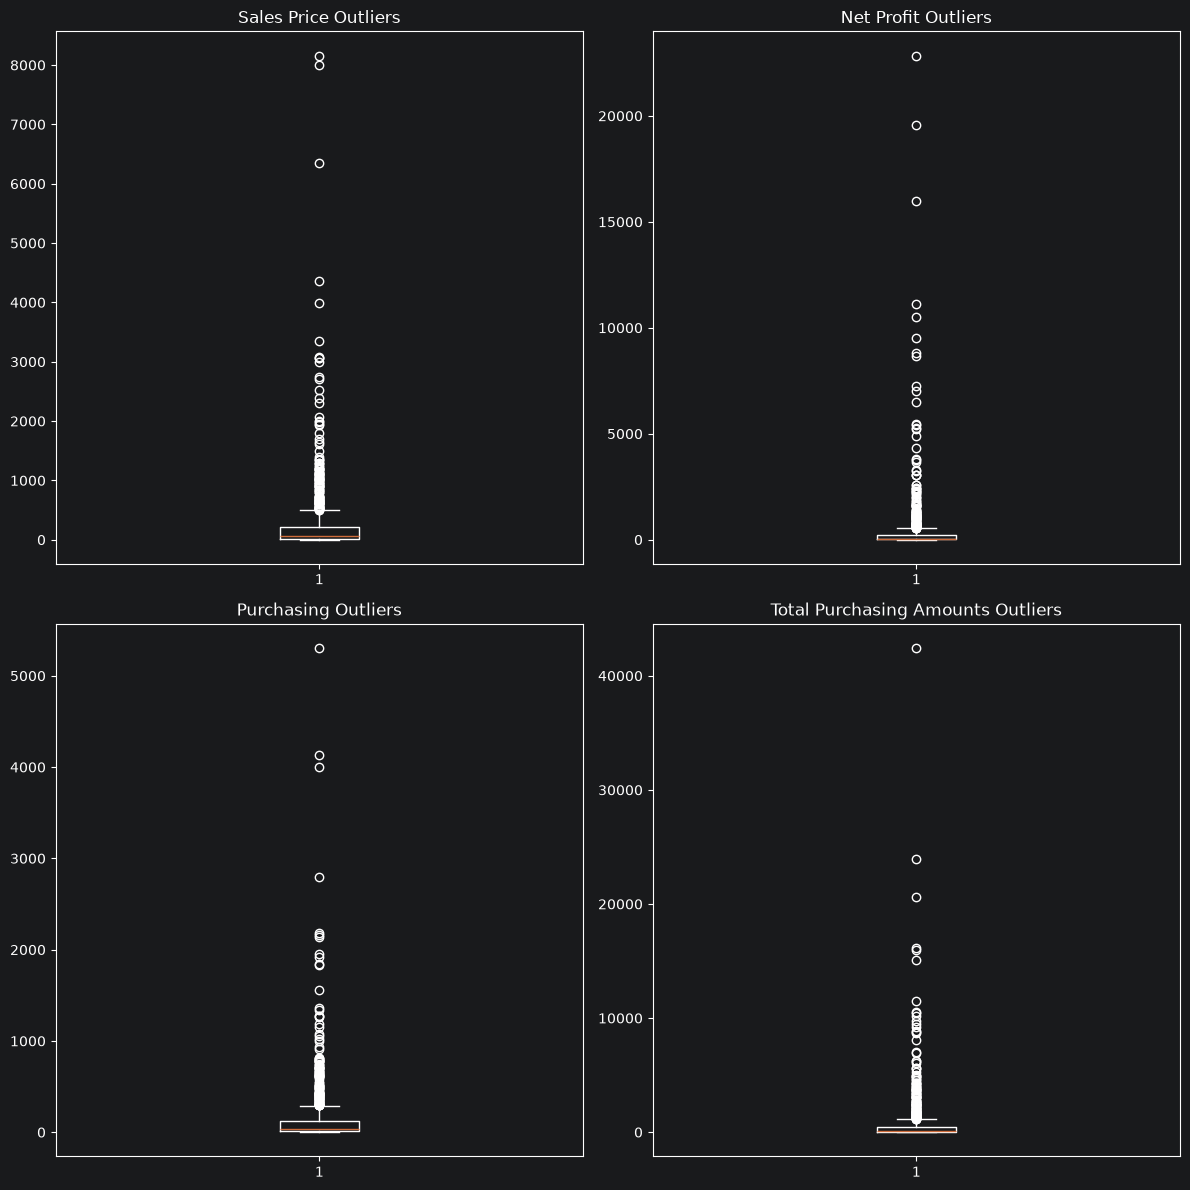

In [266]:

fig ,ax = plt.subplots(2,2,figsize=(12,12))
ax[0][0].boxplot(data=data,x='Sales Price'),ax[0][0].set_title('Sales Price Outliers')
ax[0][1].boxplot(data=data,x='Net Profit'),ax[0][1].set_title('Net Profit Outliers')
ax[1][0].boxplot(data=data,x='Purchasing Price'),ax[1][0].set_title('Purchasing Outliers')
ax[1][1].boxplot(data=data,x='Total Purchasing Amounts'),ax[1][1].set_title('Total Purchasing Amounts Outliers')
plt.tight_layout()

Bivarite


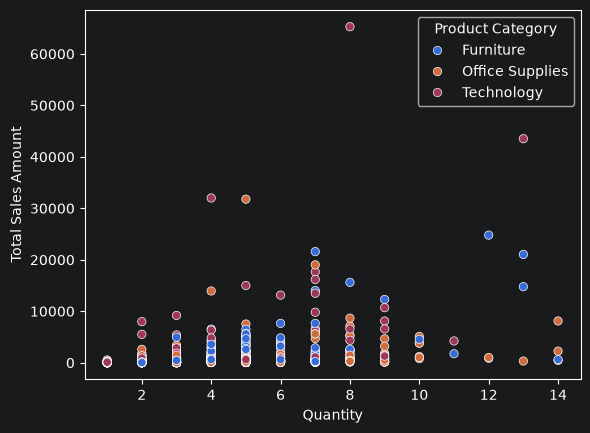

In [267]:
sns.scatterplot(data,x='Quantity',y='Total Sales Amount',hue='Product Category')
plt.show()

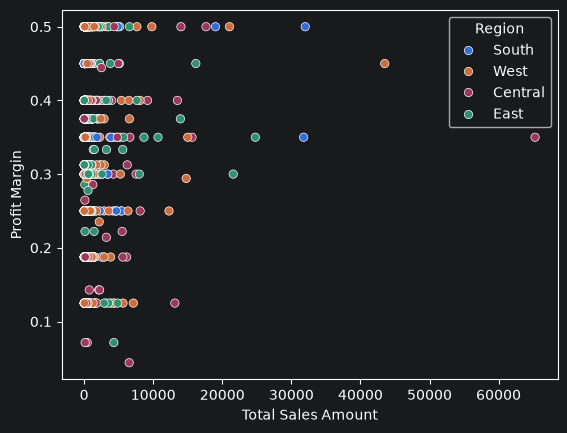

In [268]:
sns.scatterplot(
    data=data,
    x='Total Sales Amount',
    y='Profit Margin',hue='Region',
)
plt.show()

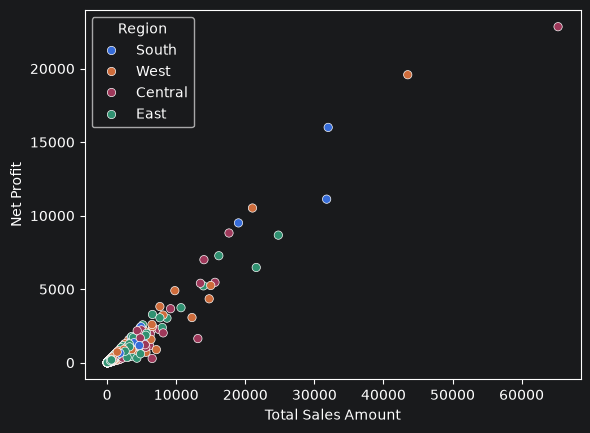

In [269]:
sns.scatterplot(data,x='Total Sales Amount',y='Net Profit',hue='Region')
plt.show()

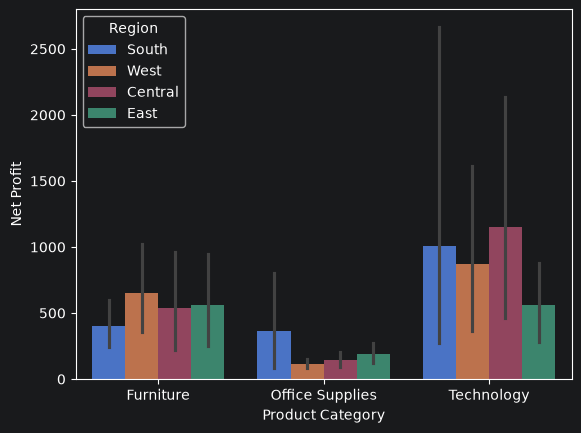

In [270]:
sns.barplot(data,x='Product Category', y='Net Profit', hue='Region')
plt.show()

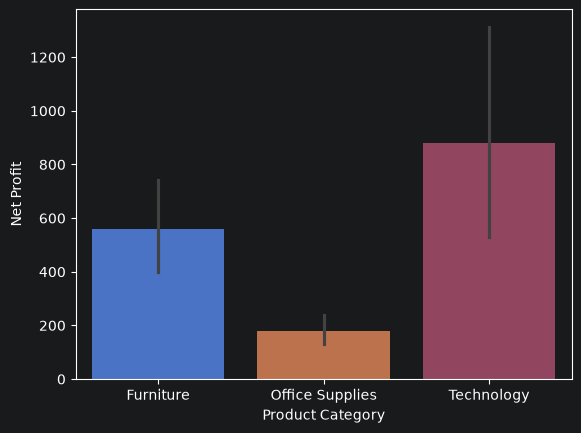

In [272]:
sns.barplot(data,x='Product Category' ,y='Net Profit',hue=data['Product Category'])
plt.show()

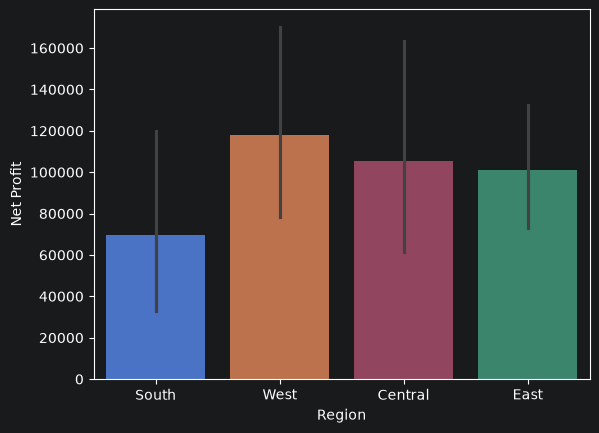

In [273]:
sns.barplot(data,x='Region',y='Net Profit',estimator='sum',hue='Region')
plt.show()

In [274]:
pd.crosstab(data['Region'],data['Product Category'])

Product Category,Furniture,Office Supplies,Technology
Region,,,
Central,44,145,53
East,59,200,54
South,35,80,26
West,66,184,61


In [4]:
sns.heatmap(pd.crosstab(data['Region'],data['Product Category']))

NameError: name 'sns' is not defined

<Axes: xlabel='Total Sales Amount', ylabel='Net Profit'>

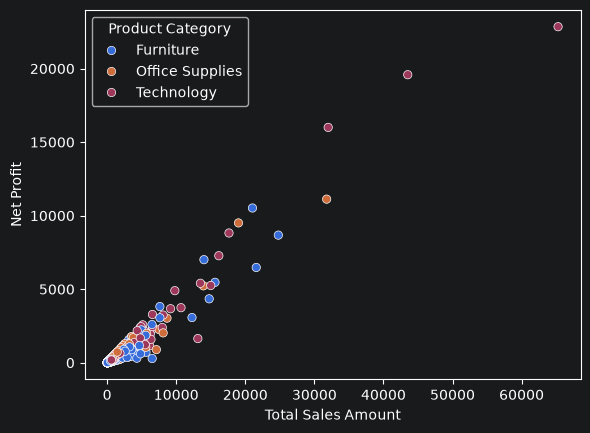

In [276]:
sns.scatterplot(
    data=data,
    x='Total Sales Amount',
    y='Net Profit',
    hue='Product Category'
)

<Axes: xlabel='Year', ylabel='Net Profit'>

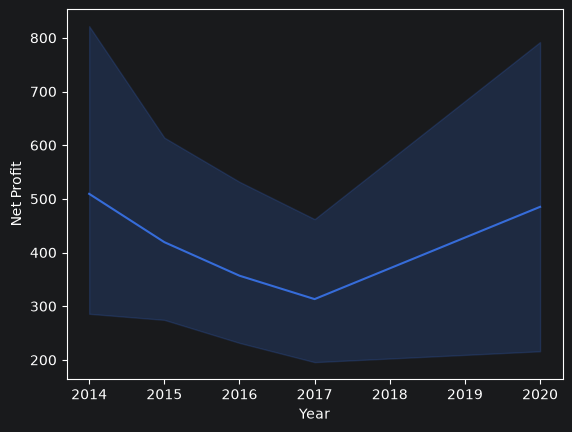

In [277]:
sns.lineplot(data,x='Year',y='Net Profit')

<Axes: xlabel='Month', ylabel='Net Profit'>

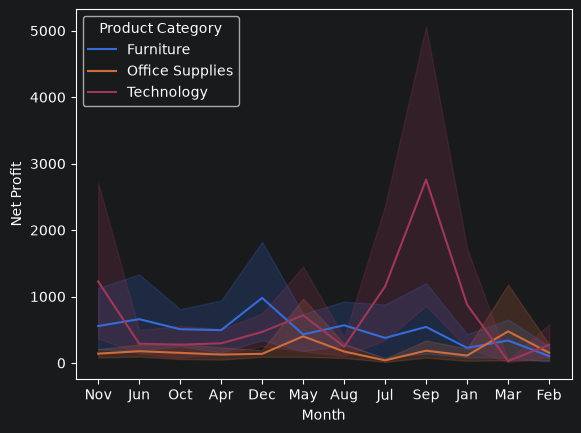

In [278]:
sns.lineplot(data,x='Month',y='Net Profit',hue='Product Category')

<Axes: >

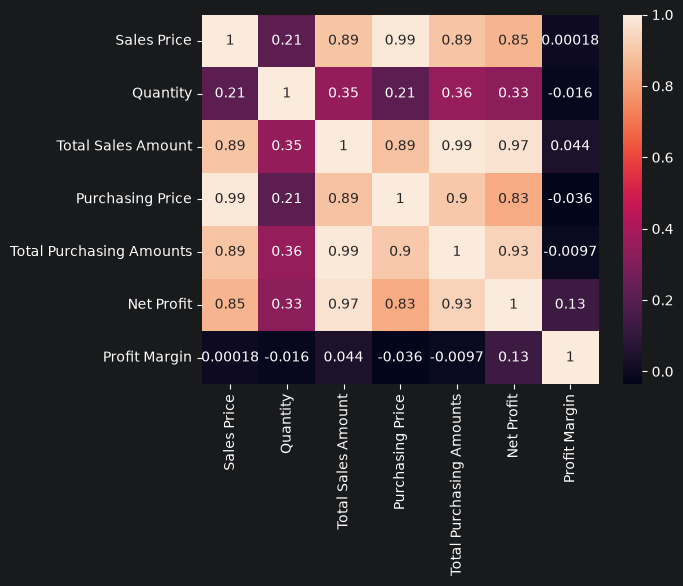

In [279]:
num_cols = [
    'Sales Price',
    'Quantity',
    'Total Sales Amount',
    'Purchasing Price',
    'Total Purchasing Amounts',
    'Net Profit',
    'Profit Margin'
]

sns.heatmap(
    data[num_cols].corr(),
    annot=True
)

<Figure size 640x480 with 0 Axes>

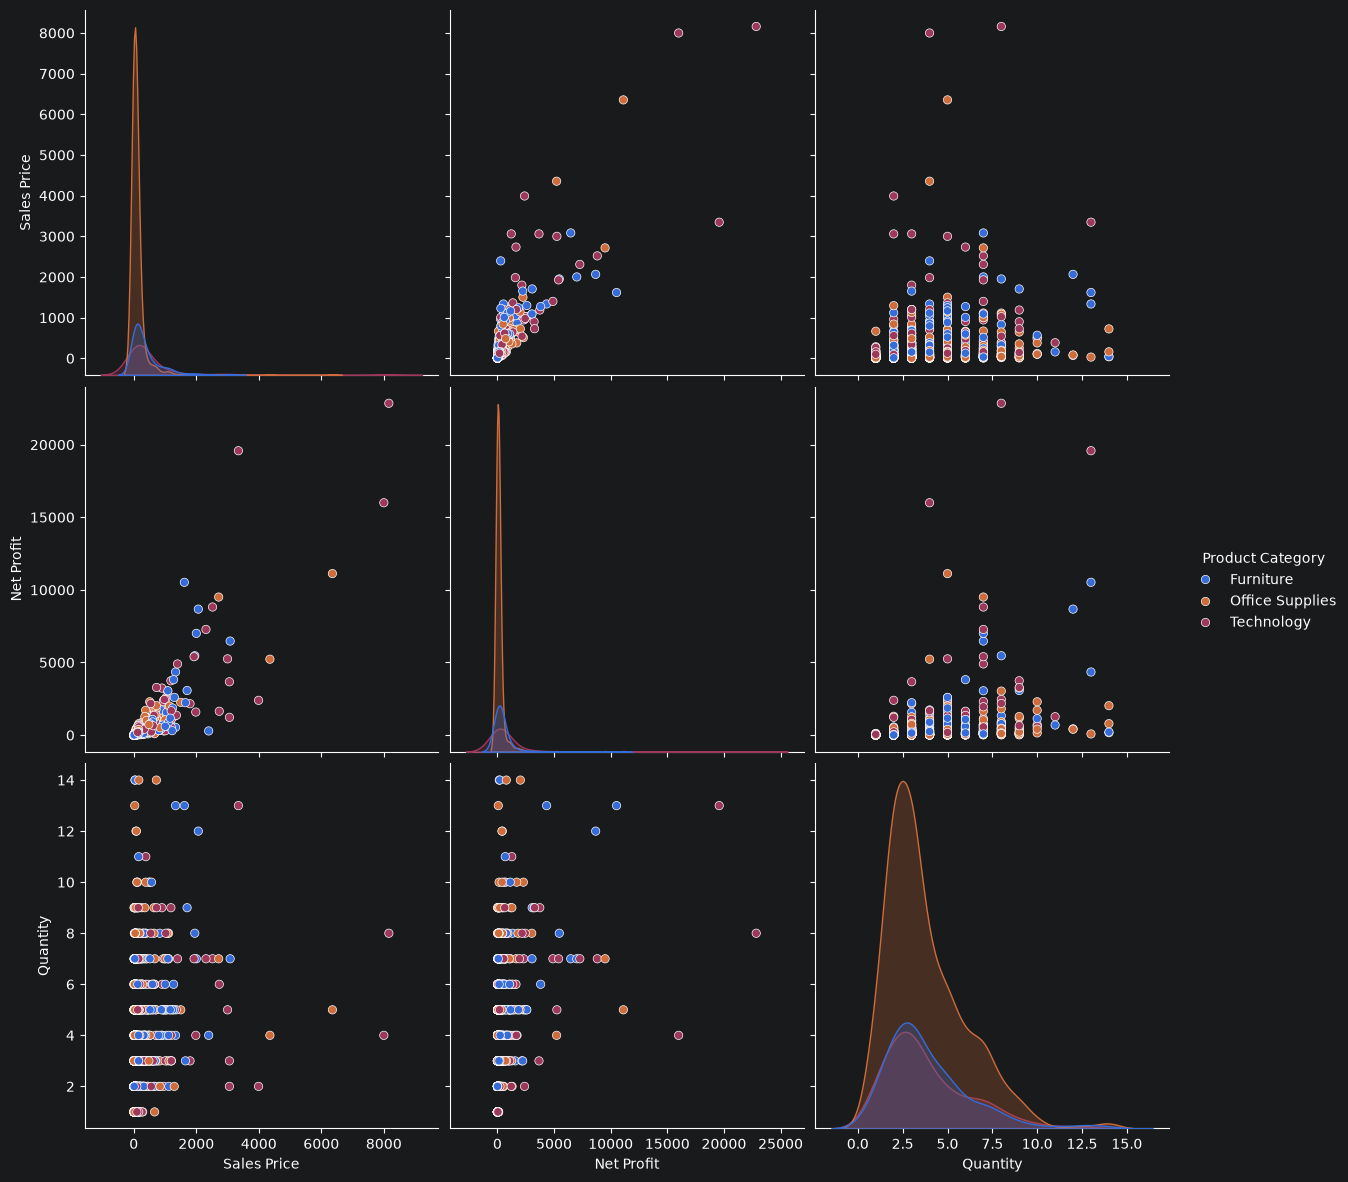

In [280]:
plt.figure()
sns.pairplot(data=data[['Sales Price','Net Profit','Quantity','Product Category']],height=4,hue='Product Category')

<Figure size 640x480 with 0 Axes>

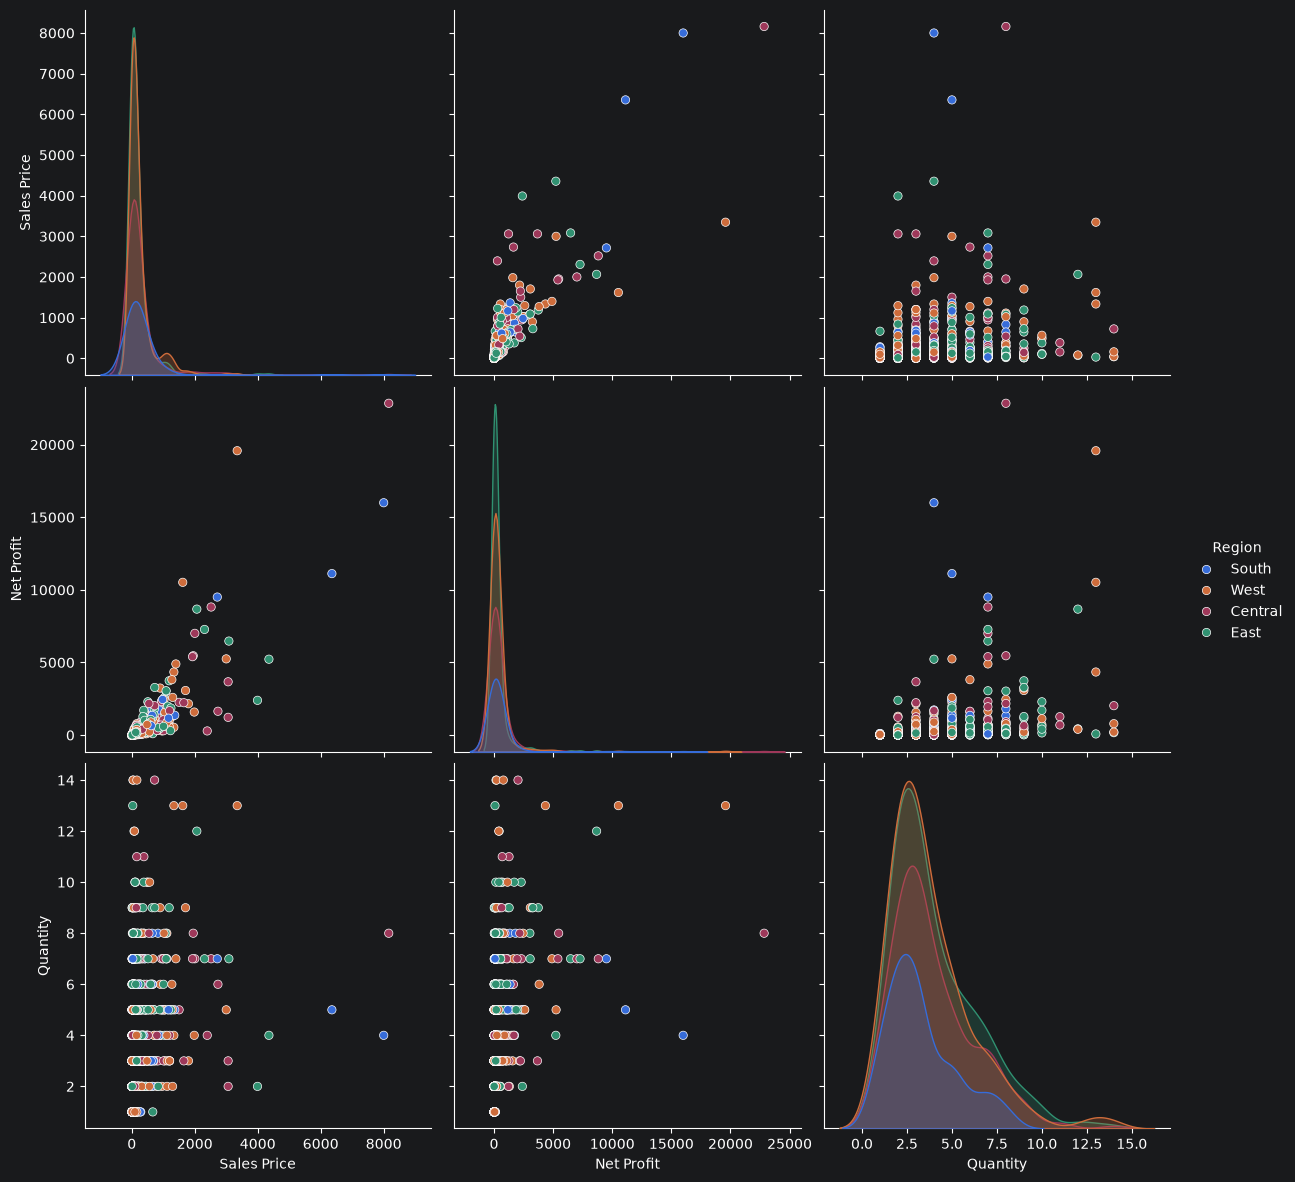

In [281]:
plt.figure()
sns.pairplot(data=data[['Sales Price','Net Profit','Quantity','Region']],height=4,hue='Region')

In [283]:
data.columns

Index(['Order ID', 'Year', 'Month', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Client Segment', 'Country', 'State',
       'Postal Code', 'Region', 'Product ID', 'Product Category',
       'Sub-Category', 'Product Name', 'Sales Price', 'Quantity', 'Discount',
       'Total Sales Amount', 'Purchasing Price', 'Total Purchasing Amounts',
       'Net Profit', 'Shipping Days', 'Profit Margin',
       'Sales Performance Category'],
      dtype='str')

In [289]:
def create_kpi(data):
    sales = data['Total Sales Amount'].sum()
    orders = data['Order ID'].nunique()
    profit = data['Net Profit'].sum()
    return {
        'Total Sales': sales,
        'Total Orders': orders,
        'Total Profit': profit,
        'Average Order Value': sales / orders,
        'Overall Profit Margin %': profit / sales * 100,
        'Most Common Ship Mode': data['Ship Mode'].mode()[0],
    }

for x, y in create_kpi(data).items():
    if isinstance(y, str):
        print(f'{x}: {y}')
    elif isinstance(y, int):
        print(f'{x}: {y:,}')
    else:
        print(f'{x}: {y:,.2f}')


def shipping_kpis(data):
    return {
        'Average Shipping Duration (days)': data['Shipping Days'].mean(),
        'Median Shipping Duration (days)': data['Shipping Days'].median(),
        'Fastest Shipping Duration (days)': data['Shipping Days'].min(),
        'Slowest Shipping Duration (days)': data['Shipping Days'].max(),
        'Avg Shipping Duration by Ship Mode': data.groupby('Ship Mode')['Shipping Days'].mean(),
        'Avg Shipping Duration by Region': data.groupby('Region')['Shipping Days'].mean(),
    }

for x, y in shipping_kpis(data).items():
    print(x, ':', y)



with open('kpi.txt','w+') as f:
    f.write('"Kpi Summary"\n')
    f.write('\n"General KPI"\n')
    for x, y in create_kpi(data).items():
        f.write(f'\n{x}: {y}\n')
    f.write('\n"SHIPPING KPI"\n')
    for x, y in shipping_kpis(data).items():
        f.write(f'\n{x}: {y}\n')



#• Optimize data frame operations and memory usage for performance.
print(data.memory_usage(deep=True).sum())


data['Product Category'] = data['Product Category'].astype('category')

data['Quantity'] = data['Quantity'].astype('int32')

data['Sub-Category'] = data['Sub-Category'].astype('category')
data['Product Name'] = data['Product Name'].astype('category')
data['Sales Price'] = data['Sales Price'].astype('float32')
data['Quantity'] = data['Quantity'].astype('float32')
data['Discount'] = data['Discount'].astype('float32')
data['Total Sales Amount'] = data['Total Sales Amount'].astype('float32')
data['Purchasing Price'] = data['Purchasing Price'].astype('float32')
data['Total Purchasing Amounts'] = data['Total Purchasing Amounts'].astype('float32')
data['Net Profit'] = data['Net Profit'].astype('float32')
data['Ship Mode'] = data['Ship Mode'].astype('category')
data['Customer ID'] = data['Customer ID'].astype('category')
data['Customer Name'] = data['Customer Name'].astype('category')
data['Client Segment'] = data['Client Segment'].astype('category')
data['Country'] = data['Country'].astype('category')
data['State'] = data['State'].astype('category')

Total Sales: 1,122,111.88
Total Orders: 488
Total Profit: 393,700.50
Average Order Value: 2,299.41
Overall Profit Margin %: 35.09
Most Common Ship Mode: Standard Class
Average Shipping Duration (days) : 4.009930486593843
Median Shipping Duration (days) : 4.0
Fastest Shipping Duration (days) : 0
Slowest Shipping Duration (days) : 7
Avg Shipping Duration by Ship Mode : Ship Mode
First Class       2.210811
Same Day          0.000000
Second Class      3.193548
Standard Class    5.010239
Name: Shipping Days, dtype: float64
Avg Shipping Duration by Region : Region
Central    4.169421
East       3.785942
South      4.078014
West       4.080386
Name: Shipping Days, dtype: float64
441243
